# Part A

# Cell 1 - Extract Source 1 (CSV)

In [1]:
import pandas as pd

# SOURCE 1: Online Retail II transactions 
# Extract raw transactional data. Latin-1 encoding avoids UnicodeDecodeError
retail_raw = pd.read_csv(r"C:\Users\kgeet\Downloads\online_retail_II.csv", encoding="ISO-8859-1")

# Evidence of successful extraction
print("Retail shape:", retail_raw.shape)         
print("Columns:", list(retail_raw.columns))     
retail_raw.head()

Retail shape: (1067371, 8)
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


# Cell 2 - Extract Source 2 from SQLite database

In [2]:
import pandas as pd
import sqlite3

# SOURCE 2: Countries of the World 
COUNTRIES_PATH = r"C:\Users\kgeet\Downloads\countries of the world-selected-columns.csv"   

# Read the real reference dataset (US World Factbook data) into a DataFrame.
countries_csv = pd.read_csv(COUNTRIES_PATH)        

# LOAD it into a local SQLite database (the relational data store)
conn = sqlite3.connect("world_reference.db")       # creates the .db file if it doesn't exist
countries_csv.to_sql("countries", conn, if_exists="replace", index=False)  # write the table

# EXTRACT via SQL: project only the columns we need for enrichment.
# "GDP ($ per capita)" MUST be double-quoted in SQL because it contains spaces and symbols.
query = '''
    SELECT Country,
           Region,
           Population,
           "GDP ($ per capita)" AS GDP_per_capita
    FROM countries;
'''
countries_raw = pd.read_sql_query(query, conn)     # run query to get the Dataset
conn.close()                                       # close the connection

# Evidence of successful extraction
print("Countries extracted from DB:", countries_raw.shape)  
countries_raw.head()

Countries extracted from DB: (227, 4)


,Country,Region,Population,GDP_per_capita
0,Afghanistan,ASIA (EX. NEAR EAST),31056997,700.0
1,Albania,EASTERN EUROPE,3581655,4500.0
2,Algeria,NORTHERN AFRICA,32930091,6000.0
3,American Samoa,OCEANIA,57794,8000.0
4,Andorra,WESTERN EUROPE,71201,19000.0


# Cell 3 - Transform the retail frame

In [3]:
import pandas as pd

# Work on a copy so the raw extract stays intact 
retail = retail_raw.copy()
start_rows = len(retail)

# (a) Rename columns for consistency 
retail = retail.rename(columns={
    "Invoice":      "invoice",
    "StockCode":    "stock_code",
    "Description":  "description",
    "Quantity":     "quantity",
    "InvoiceDate":  "invoice_date",
    "Price":        "price",
    "Customer ID":  "customer_id",   # removes the awkward space in the original name
    "Country":      "country",
})

# (b) Validate/convert data types
retail["invoice_date"] = pd.to_datetime(retail["invoice_date"])  # Converting to datetime datatype
retail["invoice"]      = retail["invoice"].astype(str)           # Converting to string datatype
retail["country"]      = retail["country"].str.strip()           # trim any stray whitespace

# (c) Remove cancelled orders 
cancellations = retail["invoice"].str.startswith("C").sum()
retail = retail[~retail["invoice"].str.startswith("C")]

# (d) Remove invalid transactions (a real sale needs a positive quantity AND price)
bad_qty_price = ((retail["quantity"] <= 0) | (retail["price"] <= 0)).sum()
retail = retail[(retail["quantity"] > 0) & (retail["price"] > 0)]

# (e) Handle missing values
missing_customer = retail["customer_id"].isna().sum()   
missing_desc     = retail["description"].isna().sum()
retail = retail.dropna(subset=["customer_id", "description"])  # keep only attributable sales

# (f) Fix customer_id type  
retail["customer_id"] = retail["customer_id"].astype("int64")

# (g) Remove exact duplicate rows
duplicates = retail.duplicated().sum()
retail = retail.drop_duplicates()

# (h) Create derived fields
retail["revenue"]       = retail["quantity"] * retail["price"]   # line-level sales value
retail["invoice_year"]  = retail["invoice_date"].dt.year         # enables time-based analysis
retail["invoice_month"] = retail["invoice_date"].dt.month

retail_clean = retail.reset_index(drop=True)

# Cleaning audit trail 
print("RETAIL CLEANING SUMMARY")
print(f"  Starting rows:             {start_rows:,}")
print(f"  Cancellations removed:     {cancellations:,}")
print(f"  Invalid qty/price removed: {bad_qty_price:,}")
print(f"  Missing customer_id:       {missing_customer:,}")
print(f"  Missing description:       {missing_desc:,}")
print(f"  Duplicate rows removed:    {duplicates:,}")
print(f"  Final clean rows:          {len(retail_clean):,}")
retail_clean.head()

RETAIL CLEANING SUMMARY
  Starting rows:             1,067,371
  Cancellations removed:     19,494
  Invalid qty/price removed: 6,207
  Missing customer_id:       236,121
  Missing description:       0
  Duplicate rows removed:    26,124
  Final clean rows:          779,425


,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country,revenue,invoice_year,invoice_month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009,12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009,12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009,12


# Cell 4 - Transform the countries frame

In [4]:
import pandas as pd
import numpy as np

# Work on a copy of the extracted reference data
countries = countries_raw.copy()

# (a) Rename columns
countries = countries.rename(columns={
    "Country":        "country",
    "Region":         "region",
    "Population":      "population",
    "GDP_per_capita": "gdp_per_capita",
})

# (b) Clean text fields
# This dataset pads values with trailing spaces and writes regions in uneven UPPERCASE.
countries["country"] = countries["country"].str.strip()                  # remove trailing spaces
countries["region"]  = (countries["region"].str.strip()                  # trim
                        .str.replace(r"\s+", " ", regex=True)            # collapse multiple spaces
                        .str.title())                                    # readable Title Case

# (c) Check missing values
missing_gdp = countries["gdp_per_capita"].isna().sum()  
missing_pop = countries["population"].isna().sum()

# (d) Derived field: classify each country into an income group from GDP per capita 
bins   = [0, 2000, 10000, 25000, np.inf]                 
labels = ["Low", "Lower-middle", "Upper-middle", "High"]
countries["income_group"] = pd.cut(countries["gdp_per_capita"], bins=bins, labels=labels)
# the country with no GDP stays NaN because we can't predict a country's GDP

countries_clean = countries.reset_index(drop=True)

# Evidence
print("COUNTRIES CLEANING SUMMARY")
print(f"  Rows:                   {len(countries_clean)}")
print(f"  Missing gdp_per_capita: {missing_gdp}")
print(f"  Missing population:     {missing_pop}")
print("\nIncome group counts:")
print(countries_clean["income_group"].value_counts(dropna=False).to_string())
countries_clean.head()

COUNTRIES CLEANING SUMMARY
  Rows:                   227
  Missing gdp_per_capita: 1
  Missing population:     0

Income group counts:
income_group
Lower-middle    89
Low             61
Upper-middle    51
High            25
NaN              1


,country,region,population,gdp_per_capita,income_group
0,Afghanistan,Asia (Ex. Near East),31056997,700.0,Low
1,Albania,Eastern Europe,3581655,4500.0,Lower-middle
2,Algeria,Northern Africa,32930091,6000.0,Lower-middle
3,American Samoa,Oceania,57794,8000.0,Lower-middle
4,Andorra,Western Europe,71201,19000.0,Upper-middle


# Cell 5 - Load (integrate and persist)

In [5]:
import pandas as pd
import sqlite3

# (a) Harmonise the join key: map retail country spellings to the reference names
name_map = {
    "EIRE":  "Ireland",
    "USA":   "United States",
    "RSA":   "South Africa",
    "Korea": "Korea, South",
}
# keep original 'country' and add a standardised 'country_ref' used only for joining
retail_clean["country_ref"] = retail_clean["country"].replace(name_map)

# (b) Integrate: LEFT join keeps every transaction, enriches where a match exists
retail_enriched = retail_clean.merge(
    countries_clean.rename(columns={"country": "country_ref"}),  
    on="country_ref",
    how="left",          # left join makes sure no sales rows are lost even if a country has no reference
)

# (c) Integration audit
matched   = retail_enriched["region"].notna().sum()
unmatched = retail_enriched["region"].isna().sum()
print("LOADING / INTEGRATION SUMMARY")
print(f"  Unified shape:      {retail_enriched.shape}")
print(f"  Rows enriched:      {matched:,}  ({matched/len(retail_enriched)*100:.1f}%)")
print(f"  Rows not enriched:  {unmatched:,}")
print("\n  Unmatched values (not present in the country reference):")
print(retail_enriched.loc[retail_enriched['region'].isna(), 'country'].value_counts().to_string())

# (d) Load the unified table into a relational store
conn = sqlite3.connect("retail_warehouse.db")
retail_enriched.to_sql("retail_enriched", conn, if_exists="replace", index=False)
loaded = pd.read_sql_query("SELECT COUNT(*) AS n FROM retail_enriched;", conn).iloc[0, 0]
conn.close()
print(f"\n  Loaded into SQLite table 'retail_enriched': {loaded:,} rows")

retail_enriched.head()

LOADING / INTEGRATION SUMMARY
  Unified shape:      (779425, 16)
  Rows enriched:      777,242  (99.7%)
  Rows not enriched:  2,183

  Unmatched values (not present in the country reference):
country
Channel Islands       1551
Unspecified            518
European Community      60
West Indies             54

  Loaded into SQLite table 'retail_enriched': 779,425 rows


,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country,revenue,invoice_year,invoice_month,country_ref,region,population,gdp_per_capita,income_group
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009,12,United Kingdom,Western Europe,60609153.0,27700.0,High
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,United Kingdom,Western Europe,60609153.0,27700.0,High
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,United Kingdom,Western Europe,60609153.0,27700.0,High
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009,12,United Kingdom,Western Europe,60609153.0,27700.0,High
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009,12,United Kingdom,Western Europe,60609153.0,27700.0,High


# Cell 6 - Summary statistics and value counts (Part A and Part B)

In [6]:
# (a) Summary statistics on the key numeric fields
print("SUMMARY STATISTICS (quantity, price, revenue)")
print(retail_enriched[["quantity", "price", "revenue"]].describe().round(2))
print(f"\nTotal revenue across all transactions: £{retail_enriched['revenue'].sum():,.0f}")

# (b) Value counts/frequency tables for THREE key columns
print("\nTOP 10 COUNTRIES by number of transactions:")
print(retail_enriched["country"].value_counts().head(10))      # raw geography

print("\nTRANSACTIONS BY REGION:")                              # from the integration
print(retail_enriched["region"].value_counts(dropna=False))

print("\nTRANSACTIONS BY INCOME GROUP:")                        # the derived field
print(retail_enriched["income_group"].value_counts(dropna=False))

SUMMARY STATISTICS (quantity, price, revenue)
        quantity      price    revenue
count  779425.00  779425.00  779425.00
mean       13.49       3.22      22.29
std       145.86      29.68     227.43
min         1.00       0.00       0.00
25%         2.00       1.25       4.95
50%         6.00       1.95      12.48
75%        12.00       3.75      19.80
max     80995.00   10953.50  168469.60

Total revenue across all transactions: £17,374,804

TOP 10 COUNTRIES by number of transactions:
country
United Kingdom    700388
Germany            16432
EIRE               15565
France             13511
Netherlands         5085
Spain               3662
Belgium             3055
Switzerland         3005
Portugal            2356
Australia           1789
Name: count, dtype: int64

TRANSACTIONS BY REGION:
region
Western Europe          771000
NaN                       2183
Near East                 1951
Oceania                   1789
Asia (Ex. Near East)       936
Northern America           637
East

# Cell 7 - Visualisations

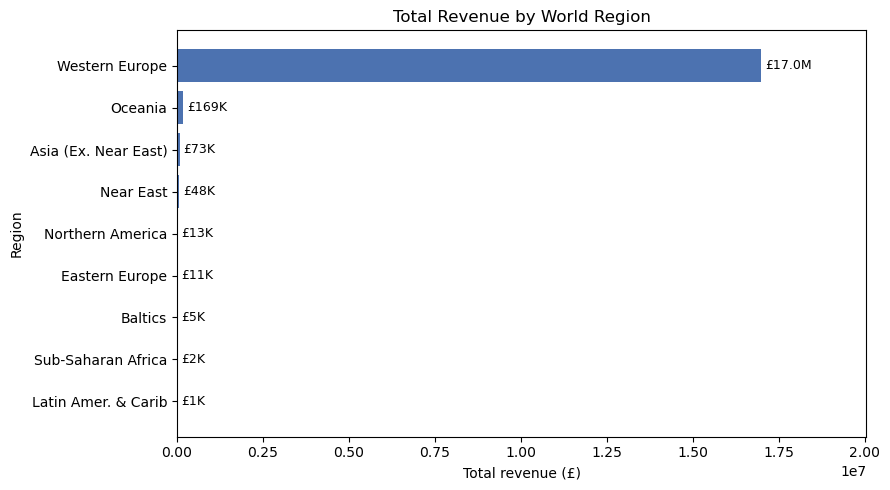

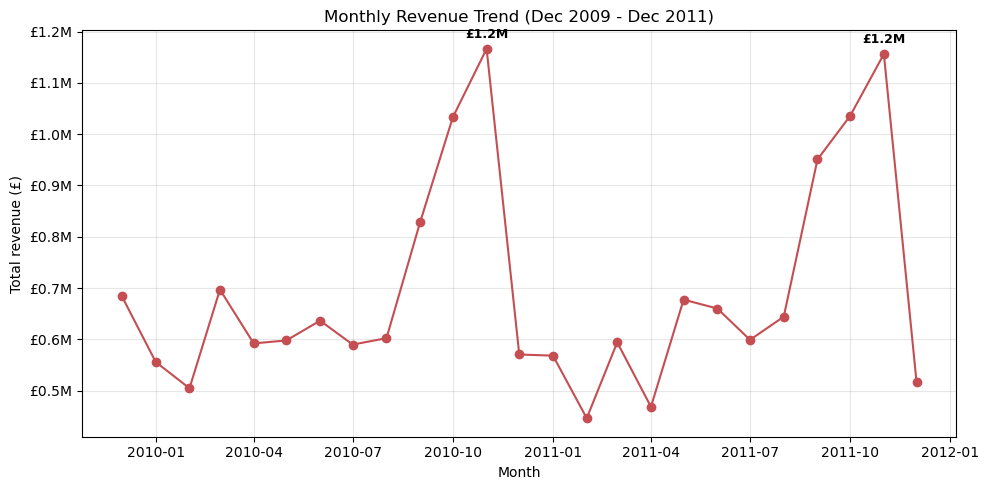

In [7]:
import matplotlib.pyplot as plt

def gbp(v):
    if v >= 1e6: return f"£{v/1e6:.1f}M"
    if v >= 1e3: return f"£{v/1e3:.0f}K"
    return f"£{v:.0f}"

# Chart 1: Total revenue by world region (horizontal bar)
rev_region = retail_enriched.groupby("region")["revenue"].sum().sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(rev_region.index, rev_region.values, color="#4C72B0")
ax.bar_label(bars, labels=[gbp(v) for v in rev_region.values], padding=3, fontsize=9)
ax.set_title("Total Revenue by World Region")
ax.set_xlabel("Total revenue (£)")
ax.set_ylabel("Region")
ax.margins(x=0.18)  
plt.tight_layout()
plt.show()

# Chart 2: Monthly revenue trend (line)
monthly = (retail_enriched.groupby(["invoice_year", "invoice_month"])["revenue"]
           .sum().reset_index())
monthly["period"] = pd.to_datetime(dict(year=monthly["invoice_year"],
                                        month=monthly["invoice_month"], day=1))
monthly = monthly.sort_values("period")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly["period"], monthly["revenue"], marker="o", color="#C44E52")
ax.set_title("Monthly Revenue Trend (Dec 2009 - Dec 2011)")
ax.set_xlabel("Month")
ax.set_ylabel("Total revenue (£)")
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(lambda v, _: f"£{v/1e6:.1f}M")
for _, r in monthly.nlargest(2, "revenue").iterrows():    
    ax.annotate(gbp(r["revenue"]), (r["period"], r["revenue"]),
                textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.show()

In [8]:
import os
os.makedirs("data", exist_ok=True)

# Export the two CLEANED SOURCES separately 
retail_clean.to_csv("data/retail_clean.csv", index=False)         
countries_clean.to_csv("data/countries_clean.csv", index=False)   

# Also export the UNIFIED table, for flexibility downstream 
retail_enriched.to_csv("data/retail_enriched.csv", index=False)   

# Confirm what was written 
for f in sorted(os.listdir("data")):
    print(f"{f:25s} {os.path.getsize('data/'+f)/1_000_000:7.1f} MB")

countries_clean.csv           0.0 MB
retail_clean.csv             92.6 MB
retail_enriched.csv         122.9 MB


In [9]:
import os
os.makedirs("data", exist_ok=True)
print("Saving to:", os.path.abspath("data"))   # prints the full path of the data folder

Saving to: C:\Users\kgeet\data
